<h1>Visualising Sentinel-3 daily statistics</h1>

<p>From JSON files derived from SEN3_download.ipynb</p>

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

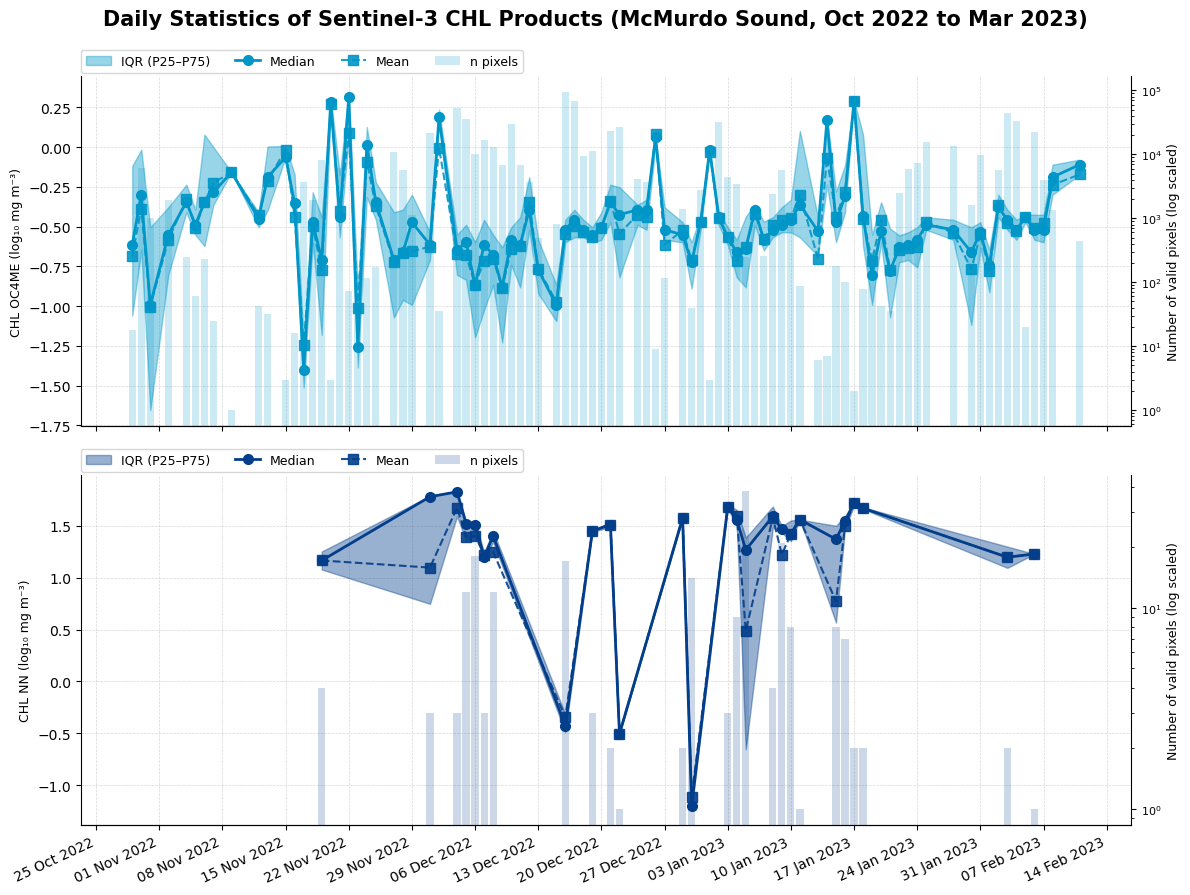

In [36]:
data = json.load(open("/Users/gwyneth/Desktop/oct2022_mar2023_summaries/oct2022_mar2023_daily_stats.json"))

dates = [datetime.strptime(d, "%Y-%m-%d") for d in data]
products = ["CHL_OC4ME", "CHL_NN"]

labels = {
    "CHL_OC4ME": "CHL OC4ME (log₁₀ mg m⁻³)",
    "CHL_NN": "CHL NN (log₁₀ mg m⁻³)",
}
colors = {
    "CHL_OC4ME": "#0096c7",
    "CHL_NN": "#023e8a",
}

series = {p: {k: [] for k in ("mean", "median", "p25", "p75", "n_pixels")} for p in products}
for date_str, day in data.items():
    for p in products:
        for k in ("mean", "median", "p25", "p75", "n_pixels"):
            series[p][k].append(day[p][k] if p in day else None)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Daily Statistics of Sentinel-3 CHL Products (McMurdo Sound, Oct 2022 to Mar 2023)", fontsize=15, fontweight="bold", y=0.99)

for ax, p in zip(axes, products):
    color = colors[p]
    dates_arr = np.array(dates)

    med = np.array(series[p]["median"],   dtype=float)
    mn  = np.array(series[p]["mean"],     dtype=float)
    p25 = np.array(series[p]["p25"],      dtype=float)
    p75 = np.array(series[p]["p75"],      dtype=float)
    npx = np.array(series[p]["n_pixels"], dtype=float)

    valid = ~np.isnan(med)
    dates_valid = dates_arr[valid]
    med_valid   = med[valid]
    mn_valid    = mn[valid]
    p25_valid   = p25[valid]
    p75_valid   = p75[valid]
    npx_valid   = npx[valid]

    # secondary y-axis for n_pixels bar chart (drawn first so it sits behind)
    ax_n = ax.twinx()
    ax_n.set_yscale("log")
    ax_n.bar(dates_valid, npx_valid, width=0.8, color=color, alpha=0.2, zorder=1, label="n pixels")
    ax_n.set_ylabel("Number of valid pixels (log scaled)", fontsize=9)
    ax_n.tick_params(axis="y", labelsize=8)
    ax_n.spines[["top", "left"]].set_visible(False)
    #ax_n.yaxis.label.set_alpha(0.6)

    # line chart on primary axis (drawn on top)
    ax.fill_between(dates_valid, p25_valid, p75_valid, alpha=0.4, color=color,
                    zorder=2, label="IQR (P25–P75)")
    ax.plot(dates_valid, med_valid, color=color, linewidth=2.0, marker="o",
            markersize=7, zorder=3, label="Median")
    ax.plot(dates_valid, mn_valid,  color=color, linewidth=1.5, marker="s",
            markersize=7, linestyle="--", alpha=0.9, zorder=3, label="Mean")

    ax.set_ylabel(labels[p], fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)

    # combined legend from both axes
    lines_main, labels_main = ax.get_legend_handles_labels()
    lines_n, labels_n = ax_n.get_legend_handles_labels()
    #ax.legend(lines_main + lines_n, labels_main + labels_n, fontsize=9, loc="upper right")
    ax.legend(lines_main + lines_n, labels_main + labels_n, fontsize=9,
          loc="lower left", bbox_to_anchor=(0, 1.01), ncols=4,
          borderaxespad=0, frameon=True)

# x-axis: weekly ticks, slanted
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=25, ha="right")

fig.tight_layout()
# fig.subplots_adjust(top=0.9)
plt.savefig("/Users/gwyneth/Desktop/oct2022_mar2023_summaries/oct2022_mar2023_dailystats_viz.png", dpi=150, bbox_inches="tight")
plt.show()